NLP Sentimental Analysis

In [332]:
!pip install requests nltk pandas

In [333]:
# import nltk
# nltk.download('punkt', quiet=True)
# nltk.download('stopwords', quiet=True)
# nltk.download('averaged_perceptron_tagger', quiet=True)
# nltk.download('punkt_tab', quiet=True)
# nltk.download('averaged_perceptron_tagger_eng')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger',quiet=True)
# nltk.download('averaged_perceptron_tagger', quiet=True)
# nltk.download('punkt_tab', quiet=True)
# nltk.download('averaged_perceptron_tagger_eng')

print("✅ All dependencies installed and ready!")

✅ All dependencies installed and ready!


In [334]:
import requests
import json
base_url = 'https://dummyjson.com'

all_product_reviews = []
def fetch_allproduct_reviews(url:str)->list:
    base = f'{base_url}/{url}'
    response = requests.get(base)
    product_list = response.json().get('products') if response.status_code == 200 else None
    reviews_list = [
        {**reviews, 'product': product.get('title')}
        for product in product_list
        for reviews in product.get('reviews',[])
    ]
    return reviews_list

all_product_reviews = fetch_allproduct_reviews('products')
print(json.dumps(all_product_reviews,indent=2))


[
  {
    "rating": 3,
    "comment": "Would not recommend!",
    "date": "2025-04-30T09:41:02.053Z",
    "reviewerName": "Eleanor Collins",
    "reviewerEmail": "eleanor.collins@x.dummyjson.com",
    "product": "Essence Mascara Lash Princess"
  },
  {
    "rating": 4,
    "comment": "Very satisfied!",
    "date": "2025-04-30T09:41:02.053Z",
    "reviewerName": "Lucas Gordon",
    "reviewerEmail": "lucas.gordon@x.dummyjson.com",
    "product": "Essence Mascara Lash Princess"
  },
  {
    "rating": 5,
    "comment": "Highly impressed!",
    "date": "2025-04-30T09:41:02.053Z",
    "reviewerName": "Eleanor Collins",
    "reviewerEmail": "eleanor.collins@x.dummyjson.com",
    "product": "Essence Mascara Lash Princess"
  },
  {
    "rating": 5,
    "comment": "Great product!",
    "date": "2025-04-30T09:41:02.053Z",
    "reviewerName": "Savannah Gomez",
    "reviewerEmail": "savannah.gomez@x.dummyjson.com",
    "product": "Eyeshadow Palette with Mirror"
  },
  {
    "rating": 4,
    "commen

In [335]:
import pandas as pd

def set_as_dataset(data:list) -> pd.DataFrame:
    rows = []
    for i in data:
        rows.append({
            'Product' : i.get('product') or "",
            'Rating' : i.get('rating') or "",
            'Review' : i.get('comment') or ""
        })
    df = pd.DataFrame(rows)
    return df

set_as_dataset(all_product_reviews)
df = set_as_dataset(all_product_reviews)
df.head()

,Product,Rating,Review
0,Essence Mascara Lash Princess,3,Would not recommend!
1,Essence Mascara Lash Princess,4,Very satisfied!
2,Essence Mascara Lash Princess,5,Highly impressed!
3,Eyeshadow Palette with Mirror,5,Great product!
4,Eyeshadow Palette with Mirror,4,Awesome product!


In [336]:
import re

PATTERNS = {
 "url" : re.compile(r'https?://\S+'),
 "html_tag" : re.compile(r"<[^>]+>"),
 "extra_space" : re.compile(r"\s+"),
 "punc" : re.compile(r"[a-zA-Z\s]"),
 "ticker": re.compile(r"\b[A-Z]{2,5}\b"),
 "year": re.compile(r"\b(19|20)\d{2}\b"),
 "proper_noun":re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),
 "chars_bracket": re.compile(r'[!]'), 
}


def clean_text(text:str)->str:
    text = PATTERNS["url"].sub(' ',text)
    text = PATTERNS["html_tag"].sub(' ',text)
    text = PATTERNS["extra_space"].sub(' ',text)
    text = PATTERNS["chars_bracket"].sub(' ',text)
    return text.strip().lower()

def proper_noun(text:str)->list:
    return PATTERNS["proper_noun"].findall(text)

def ticker(text:str)->list:
    return PATTERNS["ticker"].findall(text)

df["clean_text"] = df["Review"].apply(clean_text)
df["proper_noun"] = df["Review"].apply(proper_noun)
df["ticker"] = df["Review"].apply(ticker)

df.head()

,Product,Rating,Review,clean_text,proper_noun,ticker
0,Essence Mascara Lash Princess,3,Would not recommend!,would not recommend,[],[]
1,Essence Mascara Lash Princess,4,Very satisfied!,very satisfied,[],[]
2,Essence Mascara Lash Princess,5,Highly impressed!,highly impressed,[],[]
3,Eyeshadow Palette with Mirror,5,Great product!,great product,[],[]
4,Eyeshadow Palette with Mirror,4,Awesome product!,awesome product,[],[]


In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['would'])
print(STOP_WORDS)

def tokenize_filter(text:str)->list:
    tokenize = word_tokenize(text)
    tokenize = [i for i in tokenize if i.isalpha()]
    tokenize = [i for i in tokenize if i not in STOP_WORDS]
    tokenize = [i for i in tokenize if len(i)>2]
    return tokenize

df['tokenize'] = df['clean_text'].apply(tokenize_filter)
df.head()

{'who', 'off', 'just', 'between', 'most', 'very', 'i', 'we', 'because', 'has', 'how', 'any', 'after', "isn't", 'with', 'their', 'me', 'having', 'ain', 'isn', 'his', 'yours', 'against', 'him', 'should', 'to', 'under', "aren't", 'wasn', 'itself', "weren't", 'do', 'other', 'down', 'you', 'was', 'below', 'she', 'which', 'into', 'if', "needn't", 'each', 'being', "hadn't", 'so', 'ours', "couldn't", "it's", 'mightn', 'whom', 's', 'had', 'our', "haven't", 'its', "shouldn't", "won't", 'no', 'about', "we'd", 'the', 'now', "that'll", "she'd", 'nor', "you'll", 'same', 'needn', 'while', 'by', 'it', 've', "mustn't", 'are', 'didn', 'a', 'll', 'be', "it'd", 'm', 'such', 'd', 'once', 'than', "she's", 'some', 'of', 'my', 'hers', 'am', 'yourselves', 'own', 'more', 'o', 'but', 'as', 't', "wouldn't", 'have', 'for', 'on', "they'd", "they've", 'he', 'above', 'when', 'y', "hasn't", 'myself', 'in', "don't", 'from', 'haven', 'himself', 'all', 'can', 'further', "wasn't", 'through', 'and', "i'd", 'would', 'that',

,Product,Rating,Review,clean_text,proper_noun,ticker,tokenize
0,Essence Mascara Lash Princess,3,Would not recommend!,would not recommend,[],[],[recommend]
1,Essence Mascara Lash Princess,4,Very satisfied!,very satisfied,[],[],[satisfied]
2,Essence Mascara Lash Princess,5,Highly impressed!,highly impressed,[],[],"[highly, impressed]"
3,Eyeshadow Palette with Mirror,5,Great product!,great product,[],[],"[great, product]"
4,Eyeshadow Palette with Mirror,4,Awesome product!,awesome product,[],[],"[awesome, product]"


In [338]:
all_tokens = [token for i in df['tokenize'] for token in i]
freq_dict = FreqDist(all_tokens)
print(f'Total Tokens: {len(all_tokens)}')
print(f'Unique Tokens: {len(freq_dict)}')

top_words = freq_dict.most_common(20)

words,count = zip(*top_words)
print(words, count)

Total Tokens: 156
Unique Tokens: 27
('great', 'product', 'quality', 'highly', 'buy', 'purchase', 'impressed', 'poor', 'money', 'excellent', 'recommend', 'disappointed', 'fast', 'shipping', 'value', 'recommended', 'awesome', 'dissatisfied', 'unhappy', 'happy') (14, 14, 14, 12, 8, 8, 7, 7, 7, 7, 6, 5, 5, 5, 5, 5, 4, 4, 4, 4)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'great'),
  Text(1, 0, 'product'),
  Text(2, 0, 'quality'),
  Text(3, 0, 'highly'),
  Text(4, 0, 'buy'),
  Text(5, 0, 'purchase'),
  Text(6, 0, 'impressed'),
  Text(7, 0, 'poor'),
  Text(8, 0, 'money'),
  Text(9, 0, 'excellent'),
  Text(10, 0, 'recommend'),
  Text(11, 0, 'disappointed'),
  Text(12, 0, 'fast'),
  Text(13, 0, 'shipping'),
  Text(14, 0, 'value'),
  Text(15, 0, 'recommended'),
  Text(16, 0, 'awesome'),
  Text(17, 0, 'dissatisfied'),
  Text(18, 0, 'unhappy'),
  Text(19, 0, 'happy')])

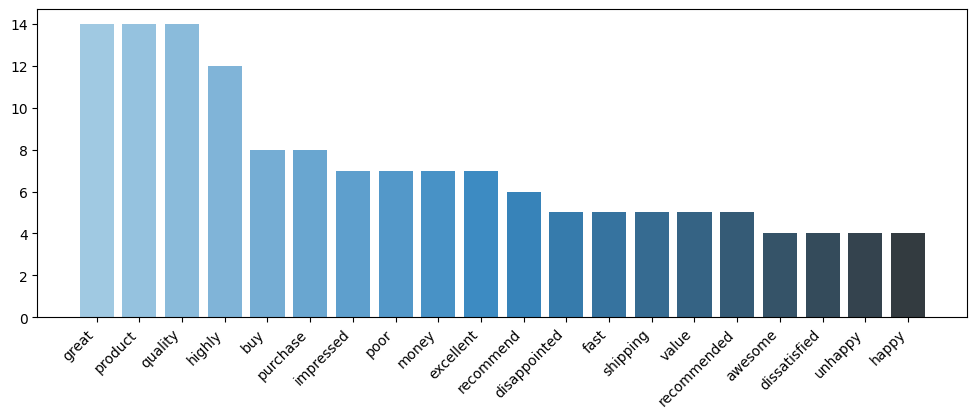

In [339]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.figure(figsize=(12,4))
bars = plt.bar(words,count,color=sns.color_palette("Blues_d", 20))
plt.xticks(rotation=45, ha='right', fontsize=10)

Sentimental Analysis

In [340]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vadar_analysis(text:str)->dict:
    score = vader.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Netural'
    return{"vader_compund" : compound, 
            "vader_positive": score["pos"],
            "vader_negative": score["neg"],
            "vader_netural": score["neu"],
            "vader_label":label
            }

def textbolb_analysis(text:str)->dict:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.5:
        label = "Postive"
    elif pol < -0.5:
        label = "Negative"
    else:
        label = "Netural"
    return {
        "TextBlob_polarity":pol,
        "TextBlob_subjectivity":subj,
        "TextBlob_Label":label
    }

vader_results = df['clean_text'].apply(vadar_analysis).apply(pd.Series)
textblob_result = df['clean_text'].apply(textbolb_analysis).apply(pd.Series)

print("Running sentiment analysis...")

df = pd.concat([df,vader_results,textblob_result],axis=1)
df.tail()


Running sentiment analysis...


,Product,Rating,Review,clean_text,proper_noun,ticker,tokenize,vader_compund,vader_positive,vader_negative,vader_netural,vader_label,TextBlob_polarity,TextBlob_subjectivity,TextBlob_Label
85,Juice,4,Would buy again!,would buy again,[],[],[buy],0.0000,0.000,0.0,1.000,Netural,0.00,0.00,Netural
86,Juice,5,Awesome product!,awesome product,[],[],"[awesome, product]",0.6249,0.804,0.0,0.196,Positive,1.00,1.00,Postive
87,Kiwi,4,Highly recommended!,highly recommended,[],[],"[highly, recommended]",0.2716,0.677,0.0,0.323,Positive,0.16,0.54,Netural
88,Kiwi,2,Would not buy again!,would not buy again,[],[],[buy],0.0000,0.000,0.0,1.000,Netural,0.00,0.00,Netural
89,Kiwi,4,Fast shipping!,fast shipping,[],[],"[fast, shipping]",0.0000,0.000,0.0,1.000,Netural,0.20,0.60,Netural


In [342]:
def final_result(row):
    if row['vader_label'] == row['TextBlob_Label']: return row['vader_label']
    if row['vader_label'] == 'Postive' and row['TextBlob_Label'] == 'Negative' : return 'Netural'
    if row['TextBlob_Label'] == 'Postive' and row['vader_label'] == 'Negative' : return 'Netural'
    return "Neutral"

df["Feedback"] = df.apply(final_result, axis=1)

df.tail()

COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

cat_sentiment = df.groupby(["Product", "Feedback"]).size().unstack(fill_value=0)
cat_sentiment['Neutral'] = cat_sentiment.get('Neutral', 0) + cat_sentiment.get('Netural', 0)
cat_sentiment.drop(columns=['Netural'], inplace=True)
print(cat_sentiment)
# # cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

Feedback                                   Negative  Neutral
Product                                                     
Annibale Colombo Bed                              0        3
Annibale Colombo Sofa                             1        2
Apple                                             1        2
Bedside Table African Cherry                      0        3
Beef Steak                                        0        3
Calvin Klein CK One                               1        2
Cat Food                                          2        1
Chanel Coco Noir Eau De                           0        3
Chicken Meat                                      0        3
Cooking Oil                                       0        3
Cucumber                                          0        3
Dior J'adore                                      0        3
Dog Food                                          0        3
Dolce Shine Eau de                                0        3
Eggs                    

In [ ]:
from datetime import datetime

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             fontsize=15, fontweight='bold')
cat_avg = df.groupby('Product')['vader_compund'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[0].barh(cat_avg.index, cat_avg.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Avg VADER Score by Category", fontweight='bold')
axes[0].set_xlabel("Mean Compound Score")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


df.to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df.shape}")
df.head()

NameError: name 'plt' is not defined